I plan to determine whether word frequency patterns can distinguish the writing styles of different authors. To do so, I will examine both The Adventures of Sherlock Holmes and The Hound of the Baskervilles by Arthur Conan Doyle. I will identify their similarities and differences in word frequency. Following this, the findings will be compared to The Time Machine written by H.G. Wells to view which words appear more often in the writings of one author compared to the other.

For this experiment, texts are collected from Project Gutenberg. Pre-processing includes making sure that all the tokens are in lowercase, deleting punctuation marks, other unneeded symbols, and removing stop words. Word frequencies are established and normalized to make sure there is a fair comparison regardless of the difference in the lengths of the books. The analysis will focus on most frequent words in the books and establishes which words are equally frequent in Doyle’s books but differ significantly in Wells’ book.

In [34]:
import requests
#import books
sherlock_url = "https://www.gutenberg.org/files/1661/1661-0.txt"
hound_url = "https://www.gutenberg.org/cache/epub/2852/pg2852.txt"
time_machine_url = "https://www.gutenberg.org/files/35/35-0.txt"

#set text
sherlock_text = requests.get(sherlock_url).text
hound_text = requests.get(hound_url).text
time_machine_text = requests.get(time_machine_url).text

In [35]:
#The ebooks on Project Gutenberg start with a header that is not a part of the original text
#this function removes the headere
def remove_gutenberg_header_footer(text):
    lines = text.splitlines()

    start_index = 0
    end_index = len(lines)

    # Find start marker
    for i, line in enumerate(lines):
        if "*** START OF THE PROJECT GUTENBERG EBOOK" in line.upper():
            
            # Skip all lines that are part of the start marker
            #Sherlock Holmes gave me a multiline header issue
            j = i
            while j < len(lines):
                if lines[j].strip().endswith("***"):
                    start_index = j + 1
                    break
                j += 1
            
            break

    # Find end marker
    for i, line in enumerate(lines[start_index:], start=start_index):
        if "*** END OF THE PROJECT GUTENBERG EBOOK" in line.upper():
            end_index = i
            break

    #Join the header into one big string
    return "\n".join(lines[start_index:end_index])

In [36]:
sherlock_clean = remove_gutenberg_header_footer(sherlock_text)
hound_clean = remove_gutenberg_header_footer(hound_text)
time_machine_clean = remove_gutenberg_header_footer(time_machine_text)

In [37]:
import re

#Convert text into word lists
def get_words(text):
    #Convert all words to lowercase
    #ignore punctuation
    words = re.findall(r"[a-z']+", text.lower())
    
    # Originally, I ran into an issue where the regex was allowing apostrophes, causing s, d and t to appear as words due to contractions
    return [word for word in words if len(word) > 1 or word in ["a", "i"]];


sherlock_words = get_words(sherlock_clean)
hound_words = get_words(hound_clean)
time_machine_words = get_words(time_machine_clean)

During this analysis, I want to examine the frequency with and without the most common English words ("The", "and", "I", etc). 


Word Frequency with Stop Words.

In [38]:
from collections import Counter

sherlock_freq = Counter(sherlock_words)
hound_freq = Counter(hound_words)
time_machine_freq = Counter(time_machine_words)

print("The Adventures of Sherlock Holmes:")
print(sherlock_freq.most_common(20))

print("\nThe Hound of the Baskervilles:")
print(hound_freq.most_common(20))

print("\nThe Time Machine:")
print(time_machine_freq.most_common(20))

The Adventures of Sherlock Holmes:
[('the', 5630), ('i', 3038), ('and', 3018), ('to', 2744), ('of', 2655), ('a', 2643), ('in', 1766), ('that', 1752), ('it', 1734), ('you', 1502), ('he', 1483), ('was', 1410), ('his', 1159), ('is', 1124), ('my', 1007), ('have', 924), ('as', 852), ('had', 831), ('with', 830), ('which', 771)]

The Hound of the Baskervilles:
[('the', 3346), ('and', 1629), ('of', 1602), ('i', 1501), ('to', 1409), ('a', 1311), ('that', 1145), ('it', 1011), ('he', 919), ('in', 912), ('you', 834), ('was', 804), ('his', 692), ('is', 624), ('have', 542), ('had', 506), ('my', 480), ('we', 466), ('with', 441), ('for', 421)]

The Time Machine:
[('the', 2284), ('i', 1268), ('and', 1245), ('of', 1162), ('a', 819), ('to', 684), ('was', 552), ('in', 546), ('that', 443), ('my', 441), ('it', 437), ('had', 354), ('me', 281), ('as', 270), ('at', 244), ('for', 221), ('with', 217), ('time', 207), ('but', 205), ('were', 158)]


Word Frequency Without Stop Words

In [39]:
#list of the most common words

stop_words = {
    "the", "and", "of", "to", "a", "in", "that", "i", "it", "was",
    "he", "is", "his", "you", "as", "had", "with", "for", "on", "but",
    "not", "at", "by", "this", "be", "have", "from", "or", "we", "they",
    "an", "were", "which", "my", "me", "so", "if", "there", "would",
    "could", "should", "do", "did", "has", "been", "are", "him", "her", 
    "she", "your", "all", "what", "no", "then", "out","when", "into", 
    "who", "our", "us", "will", "their", "them", "now",
    "some", "very", "up", "down", "one"
}

def remove_stop_words(words):
    return [word for word in words if word not in stop_words]

sherlock_filtered = remove_stop_words(sherlock_words)
hound_filtered = remove_stop_words(hound_words)
time_machine_filtered = remove_stop_words(time_machine_words)

sherlock_filtered_freq = Counter(sherlock_filtered)
hound_filtered_freq = Counter(hound_filtered)
time_machine_filtered_freq = Counter(time_machine_filtered)

print("The Adventures of Sherlock Holmes:")
print(sherlock_filtered_freq.most_common(20))

print("\nThe Hound of the Baskervilles:")
print(hound_filtered_freq.most_common(20))

print("\nThe Time Machine:")
print(time_machine_filtered_freq.most_common(20))

The Adventures of Sherlock Holmes:
[('said', 486), ('upon', 465), ('holmes', 462), ('man', 305), ('mr', 275), ('little', 269), ('see', 229), ('well', 201), ('may', 197), ('am', 185), ('over', 183), ('can', 180), ('more', 174), ('think', 174), ('room', 171), ('know', 170), ('shall', 169), ('about', 168), ('before', 164), ('must', 161)]

The Hound of the Baskervilles:
[('sir', 351), ('upon', 315), ('said', 240), ('man', 214), ('holmes', 195), ('moor', 165), ('henry', 157), ('more', 137), ('know', 118), ('watson', 117), ('baskerville', 116), ('over', 115), ('see', 113), ('well', 111), ('dr', 110), ('can', 110), ('about', 105), ('may', 102), ('how', 97), ('only', 97)]

The Time Machine:
[('time', 207), ('little', 114), ('upon', 113), ('came', 107), ('said', 89), ('machine', 88), ('saw', 88), ('these', 74), ('like', 74), ('seemed', 72), ('man', 71), ('about', 70), ('its', 69), ('thing', 66), ('traveller', 65), ('again', 62), ('white', 61), ('more', 59), ('thought', 57), ('felt', 57)]


In [40]:
#funtion for plotting
def plot_common_words(freq, title, num_words=15):
    common = freq.most_common(num_words)

    words = [word for word, count in common]
    counts = [count for word, count in common]

    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1])

    plt.title(title)
    plt.xlabel("Number of Occurrences")
    plt.ylabel("Word")

    plt.show()

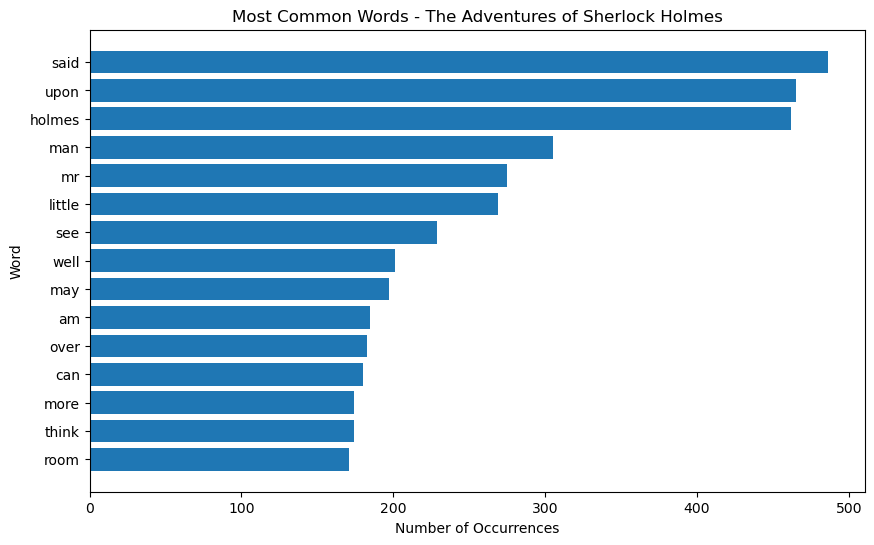

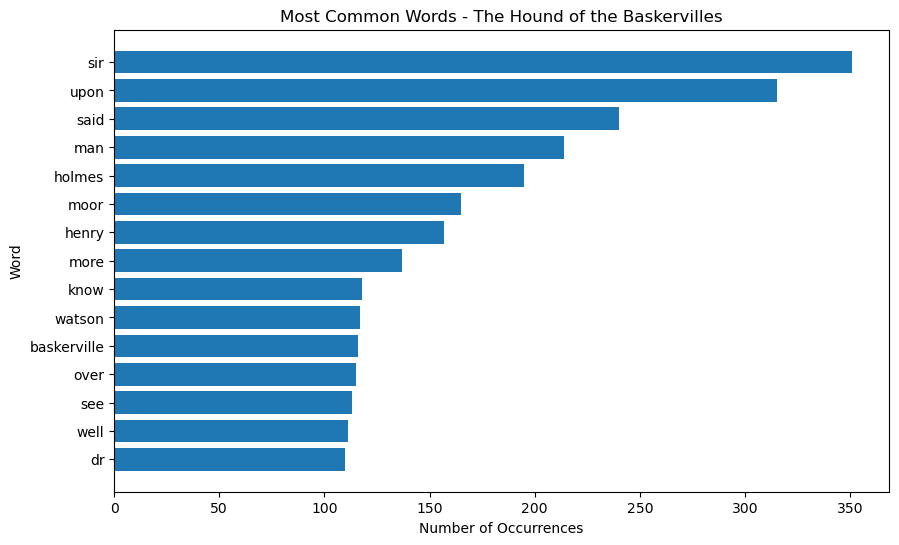

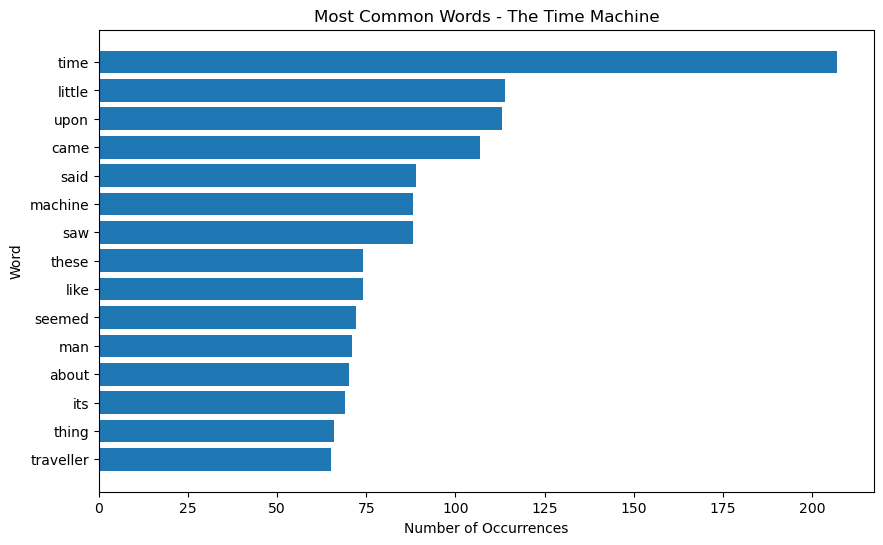

In [41]:
plot_common_words(
    sherlock_filtered_freq,
    "Most Common Words - The Adventures of Sherlock Holmes"
)
plot_common_words(
    hound_filtered_freq,
    "Most Common Words - The Hound of the Baskervilles"
)
plot_common_words(
    time_machine_filtered_freq,
    "Most Common Words - The Time Machine"
)

In [42]:
#Normalization
def per_10000(freq_dict, total_words, word):
    return (freq_dict[word] / total_words) * 10000

In [43]:
shared_words = ["said", "upon", "man", "more", "about", "see", "well", "know"]

comparison = []

for word in shared_words:
    comparison.append({
        "word": word,
        "sherlock": per_10000(
            sherlock_filtered_freq,
            len(sherlock_filtered),
            word
        ),
        "hound": per_10000(
            hound_filtered_freq,
            len(hound_filtered),
            word
        ),
        "time_machine": per_10000(
            time_machine_filtered_freq,
            len(time_machine_filtered),
            word
        )
    })

comparison

[{'word': 'said',
  'sherlock': 96.38649795724088,
  'hound': 83.72871895060005,
  'time_machine': 53.055141579731746},
 {'word': 'upon',
  'sherlock': 92.22164928007615,
  'hound': 109.89394362266256,
  'time_machine': 67.36214605067065},
 {'word': 'man',
  'sherlock': 60.4894688826306,
  'hound': 74.65810773095171,
  'time_machine': 42.32488822652757},
 {'word': 'more',
  'sherlock': 34.50874618222205,
  'hound': 47.795143734300865,
  'time_machine': 35.17138599105812},
 {'word': 'about',
  'sherlock': 33.31878941731784,
  'hound': 36.63131454088752,
  'time_machine': 41.72876304023845},
 {'word': 'see',
  'sherlock': 45.41668319384396,
  'hound': 39.42227183924086,
  'time_machine': 26.825633383010434},
 {'word': 'well',
  'sherlock': 39.863551624290984,
  'hound': 38.72453251465253,
  'time_machine': 22.056631892697467},
 {'word': 'know',
  'sherlock': 33.715441672285905,
  'hound': 41.166620150711694,
  'time_machine': 17.2876304023845}]

In [44]:
import pandas as pd

df = pd.DataFrame(comparison)

df

,word,sherlock,hound,time_machine
0,said,96.386498,83.728719,53.055142
1,upon,92.221649,109.893944,67.362146
2,man,60.489469,74.658108,42.324888
3,more,34.508746,47.795144,35.171386
4,about,33.318789,36.631315,41.728763
5,see,45.416683,39.422272,26.825633
6,well,39.863552,38.724533,22.056632
7,know,33.715442,41.166620,17.287630


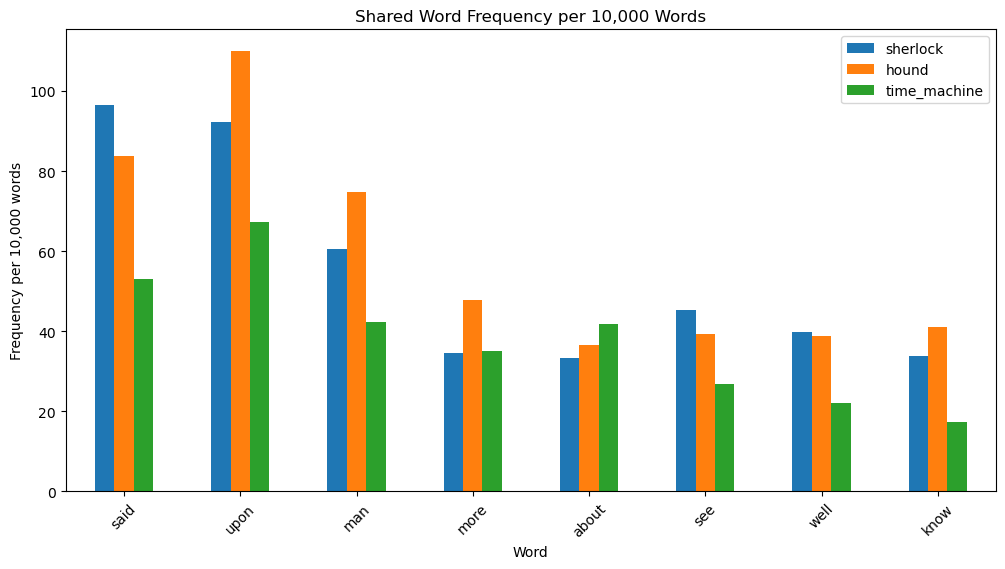

In [45]:
import matplotlib.pyplot as plt

df.set_index("word").plot(kind="bar", figsize=(12, 6))

plt.title("Shared Word Frequency per 10,000 Words")
plt.ylabel("Frequency per 10,000 words")
plt.xlabel("Word")
plt.xticks(rotation=45)

plt.show()

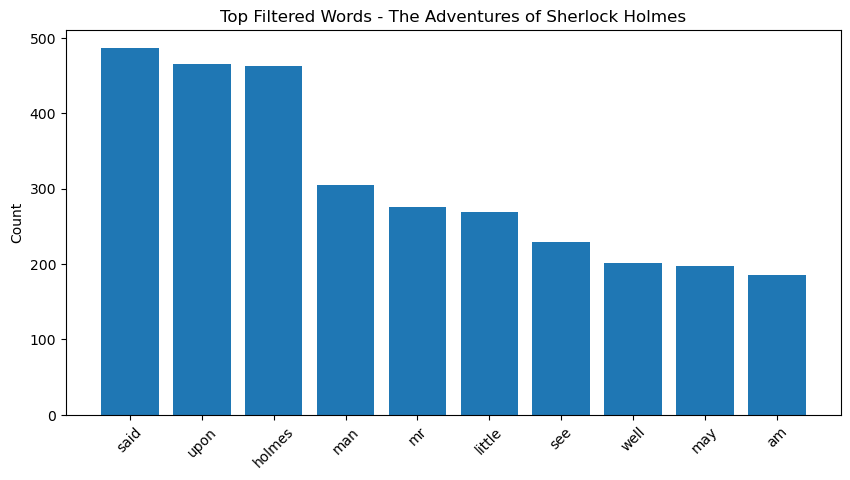

In [46]:
top_sherlock = sherlock_filtered_freq.most_common(10)

words = [x[0] for x in top_sherlock]
counts = [x[1] for x in top_sherlock]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.title("Top Filtered Words - The Adventures of Sherlock Holmes")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

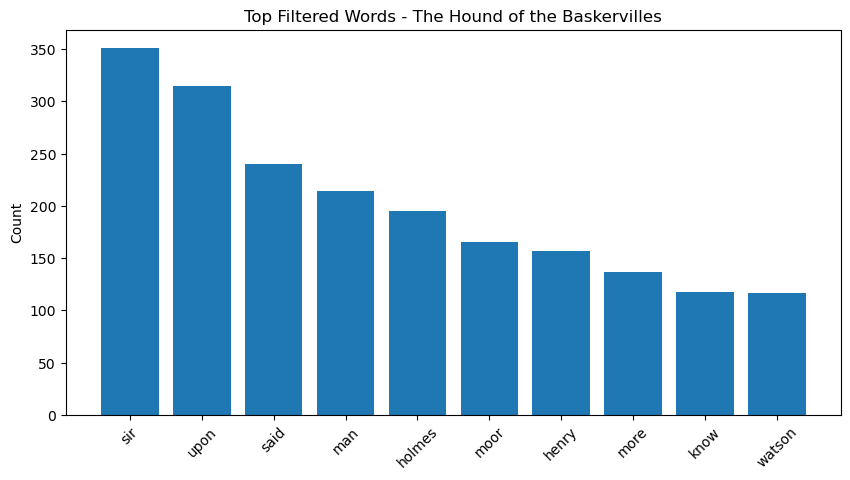

In [47]:
top_hound = hound_filtered_freq.most_common(10)

words = [x[0] for x in top_hound]
counts = [x[1] for x in top_hound]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.title("Top Filtered Words - The Hound of the Baskervilles")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

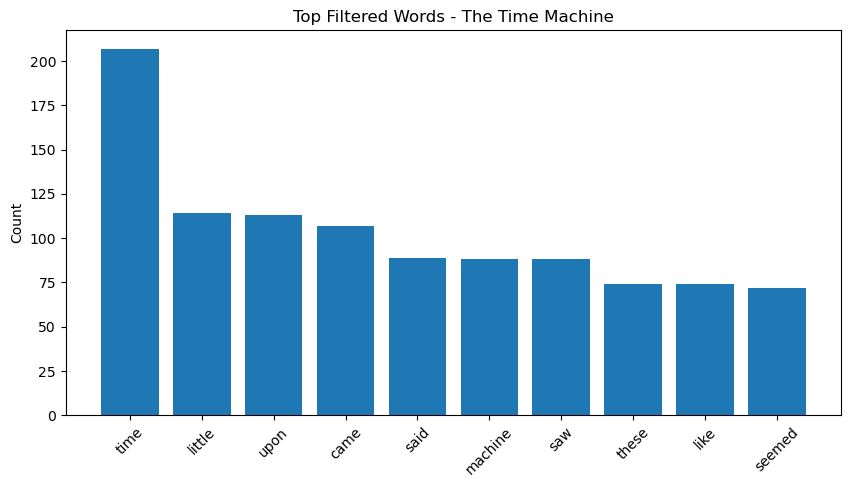

In [48]:
top_time = time_machine_filtered_freq.most_common(10)

words = [x[0] for x in top_time]
counts = [x[1] for x in top_time]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.title("Top Filtered Words - The Time Machine")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()